## Step 1: Mount Google Drive
This step connects Google Colab to Google Drive to access the dataset stored in the shared folder.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 2: Load Dataset
Load the Amazon Reviews dataset from Google Drive and display the first few rows to verify the data has been loaded correctly.

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Social Media Computing/Amazon_Reviews.csv',
                 encoding='utf-8',
                 engine='python')

print("File loaded successfully!")
print("Total rows and columns:", df.shape)
df.head(3)

File loaded successfully!
Total rows and columns: (21214, 9)


,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"


## Step 3: Exploratory Data Analysis (EDA)
Check for missing values, duplicate rows, and rating distribution to understand the quality and structure of the dataset.

In [ ]:
# Check for missing values
print("=== Missing Values ===")
print(df.isnull().sum())

# Check for duplicate rows
print("\n=== Duplicate Rows ===")
print(df.duplicated().sum())

# Check rating distribution
print("\n=== Rating Distribution ===")
print(df['Rating'].value_counts())

=== Missing Values ===
Reviewer Name           0
Profile Link           51
Country               160
Review Count          159
Review Date           159
Rating                159
Review Title          159
Review Text           159
Date of Experience    267
dtype: int64

=== Duplicate Rows ===
2

=== Rating Distribution ===
Rating
Rated 1 out of 5 stars    13123
Rated 5 out of 5 stars     4528
Rated 4 out of 5 stars     1292
Rated 2 out of 5 stars     1227
Rated 3 out of 5 stars      885
Name: count, dtype: int64


## Step 4: Data Cleaning
Remove rows with missing values in the Rating and Review Text columns, and eliminate duplicate rows to ensure data quality.

In [ ]:
# Remove rows with missing Rating and Review Text
df = df.dropna(subset=['Rating', 'Review Text'])

# Remove duplicate rows
df = df.drop_duplicates()

print("Total rows after cleaning:", len(df))

Total rows after cleaning: 21055


## Step 5: Sentiment Labeling
Convert the star ratings into sentiment labels. Ratings 1-2 are labeled as Negative, rating 3 as Neutral, and ratings 4-5 as Positive.

In [ ]:
# Extract the star number from Rating column
df['Star'] = df['Rating'].str.extract(r'(\d)').astype(int)

# Create sentiment labels based on star rating
def label_sentiment(star):
    if star <= 2:
        return 'Negative'
    elif star == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['Sentiment'] = df['Star'].apply(label_sentiment)

# Verify the result
print("=== Sentiment Distribution ===")
print(df['Sentiment'].value_counts())

=== Sentiment Distribution ===
Sentiment
Negative    14350
Positive     5820
Neutral       885
Name: count, dtype: int64


## Step 6: Save Cleaned Dataset
Save the cleaned dataset with sentiment labels to Google Drive for future use.

In [ ]:
# Keep only the columns we need
df_clean = df[['Review Text', 'Sentiment']].copy()

# Save to Google Drive
df_clean.to_csv('/content/drive/MyDrive/Social Media Computing/Amazon_Reviews_Cleaned.csv', index=False)

print("File saved successfully!")
print("Total rows:", len(df_clean))
df_clean.head(3)

File saved successfully!
Total rows: 21055


,Review Text,Sentiment
0,"I registered on the website, tried to order a ...",Negative
1,Had multiple orders one turned up and driver h...,Negative
2,I informed these reprobates that I WOULD NOT B...,Negative


In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

print("NLTK tools downloaded successfully!")

NLTK tools downloaded successfully!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Step 7: Load Cleaned Dataset
Load the cleaned dataset that will be used for text preprocessing.

In [ ]:
import pandas as pd

# Read the cleaned dataset
df = pd.read_csv('/content/drive/MyDrive/Social Media Computing/Amazon_Reviews_Cleaned.csv')

print("File loaded successfully!")
print("Total rows:", len(df))
df.head(3)

File loaded successfully!
Total rows: 21055


,Review Text,Sentiment
0,"I registered on the website, tried to order a ...",Negative
1,Had multiple orders one turned up and driver h...,Negative
2,I informed these reprobates that I WOULD NOT B...,Negative


## Step 8: Text Preprocessing Functions
Define functions for text preprocessing including URL removal, emoji removal, punctuation removal, lowercasing, tokenization, stopword removal, and lemmatization.

In [ ]:
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
custom_stopwords = {'amazon', 'item', 'product', 'order', 'one', 'get', 'got'}
stop_words = stop_words.union(custom_stopwords)
lemmatizer = WordNetLemmatizer()

def remove_urls(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    return text

def remove_emojis(text):
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U00002700-\U000027BF"
        "]+", flags=re.UNICODE)
    text = emoji_pattern.sub('', text)
    return text

def remove_punctuation(text):
    text = re.sub(r'[^\w\s]', '', text)
    return text

def lowercase(text):
    text = text.lower()
    return text

def tokenize(text):
    tokens = word_tokenize(text)
    return tokens

def remove_stopwords(tokens):
    filtered = [word for word in tokens if word not in stop_words]
    return filtered

def lemmatize(tokens):
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens]
    return lemmatized

print("All functions defined successfully!")

All functions defined successfully!


## Step 9: Test Preprocessing on Sample
Test all preprocessing functions on a single review to verify the output before applying to the entire dataset.

In [ ]:
# Test all functions on one review
sample = df['Review Text'].iloc[0]

print("=== Original ===")
print(sample)
print("")

cleaned = lowercase(remove_punctuation(remove_urls(remove_emojis(sample))))
tokens = tokenize(cleaned)
filtered = remove_stopwords(tokens)
lemmatized = lemmatize(filtered)

print("=== After all preprocessing ===")
print(lemmatized[:15])

=== Original ===
I registered on the website, tried to order a laptop, entered all the details, but instead of charging me and sending the product, they froze my account, demanding various verification documents. I sent them over. They said they would review them within 24 hours. In reality, it's been a week, and no one can help or give any (truthful) estimate of when it will be resolved; they just tell me to 'wait.' I've never seen such a horrible marketplace in my life. I hope those who came up with this can't buy food in a store, receiving a 'document review request' that takes forever to process.

=== After all preprocessing ===
['registered', 'website', 'tried', 'laptop', 'entered', 'detail', 'instead', 'charging', 'sending', 'froze', 'account', 'demanding', 'various', 'verification', 'document']


## Step 10: Apply Preprocessing to Entire Dataset
Apply all preprocessing functions to the entire dataset of 21,055 reviews and save the result.

In [ ]:
# Apply all preprocessing to the entire dataset
def preprocess(text):
    text = remove_urls(text)
    text = remove_emojis(text)
    text = remove_punctuation(text)
    text = lowercase(text)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize(tokens)
    return ' '.join(tokens)

# This will take a few minutes to run
print("Processing...")
df['Cleaned Text'] = df['Review Text'].apply(preprocess)
print("Done!")
df[['Review Text', 'Cleaned Text', 'Sentiment']].head(3)

Processing...
Done!


,Review Text,Cleaned Text,Sentiment
0,"I registered on the website, tried to order a ...",registered website tried laptop entered detail...,Negative
1,Had multiple orders one turned up and driver h...,multiple order turned driver phone door number...,Negative
2,I informed these reprobates that I WOULD NOT B...,informed reprobate would going visit sick rela...,Negative


In [ ]:
# Save the preprocessed dataset
df.to_csv('/content/drive/MyDrive/Social Media Computing/Amazon_Reviews_Preprocessed.csv', index=False)

print("File saved successfully!")
print("Total rows:", len(df))

File saved successfully!
Total rows: 21055


### Step 11: Check for Empty Strings After Preprocessing

In [ ]:
# Check for empty strings after preprocessing
empty_count = df['Cleaned Text'].str.strip().eq('').sum()
print("Empty strings after preprocessing:", empty_count)

# Remove empty strings if any
df = df[df['Cleaned Text'].str.strip() != '']
print("Total rows after removing empty strings:", len(df))

Empty strings after preprocessing: 0
Total rows after removing empty strings: 21055


## **2.0 Feature Engineering**

In [ ]:
import pandas as pd

# Load preprocessed data
df = pd.read_csv('/content/drive/MyDrive/Social Media Computing/Amazon_Reviews_Preprocessed.csv')

print("File loaded successfully!")
print("Total rows:", len(df))
df.head(3)

File loaded successfully!
Total rows: 21055


,Review Text,Sentiment,Cleaned Text
0,"I registered on the website, tried to order a ...",Negative,registered website tried laptop entered detail...
1,Had multiple orders one turned up and driver h...,Negative,multiple order turned driver phone door number...
2,I informed these reprobates that I WOULD NOT B...,Negative,informed reprobate would going visit sick rela...


### Step 1: Train-Test Split
Split the preprocessed dataset into 80% training set and 20%
testing set for model training and evaluation.

In [ ]:
from sklearn.model_selection import train_test_split

# Use Cleaned Text as input and Sentiment as output
X = df['Cleaned Text']
y = df['Sentiment']

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))

Training set size: 16844
Testing set size: 4211


### Step 2: Bag of Words (BoW)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize Bag of Words
bow_vectorizer = CountVectorizer(max_features=5000)

# Fit and transform training data
X_train_bow = bow_vectorizer.fit_transform(X_train)

# Transform testing data
X_test_bow = bow_vectorizer.transform(X_test)

print("Bag of Words - Training set shape:", X_train_bow.shape)
print("Bag of Words - Testing set shape:", X_test_bow.shape)

Bag of Words - Training set shape: (16844, 5000)
Bag of Words - Testing set shape: (4211, 5000)


### Step 3: TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform testing data
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF - Training set shape:", X_train_tfidf.shape)
print("TF-IDF - Testing set shape:", X_test_tfidf.shape)

TF-IDF - Training set shape: (16844, 5000)
TF-IDF - Testing set shape: (4211, 5000)


## **3.0 Model Training**


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# --- Without class_weight (Original) ---
lr_bow = LogisticRegression(max_iter=1000, random_state=42)
lr_bow.fit(X_train_bow, y_train)

lr_tfidf = LogisticRegression(max_iter=1000, random_state=42)
lr_tfidf.fit(X_train_tfidf, y_train)

nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)

svm_bow = LinearSVC(random_state=42, max_iter=10000)
svm_bow.fit(X_train_bow, y_train)

svm_tfidf = LinearSVC(random_state=42, max_iter=10000)
svm_tfidf.fit(X_train_tfidf, y_train)

print("Original models trained successfully!")

# --- With class_weight='balanced' ---
lr_bow_bal = LogisticRegression(max_iter=1000, random_state=42,
                                 class_weight='balanced')
lr_bow_bal.fit(X_train_bow, y_train)

lr_tfidf_bal = LogisticRegression(max_iter=1000, random_state=42,
                                   class_weight='balanced')
lr_tfidf_bal.fit(X_train_tfidf, y_train)

nb_bow_bal = MultinomialNB()
nb_bow_bal.fit(X_train_bow, y_train)

nb_tfidf_bal = MultinomialNB()
nb_tfidf_bal.fit(X_train_tfidf, y_train)

svm_bow_bal = LinearSVC(random_state=42, max_iter=10000,
                         class_weight='balanced')
svm_bow_bal.fit(X_train_bow, y_train)

svm_tfidf_bal = LinearSVC(random_state=42, max_iter=10000,
                           class_weight='balanced')
svm_tfidf_bal.fit(X_train_tfidf, y_train)

print("Balanced models trained successfully!")

Original models trained successfully!
Balanced models trained successfully!


## **4.0 Model Evaluation**
### Step 1: Evaluate All Models

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Original models
models_original = {
    'LR + BoW': (lr_bow, X_test_bow),
    'LR + TF-IDF': (lr_tfidf, X_test_tfidf),
    'NB + BoW': (nb_bow, X_test_bow),
    'NB + TF-IDF': (nb_tfidf, X_test_tfidf),
    'SVM + BoW': (svm_bow, X_test_bow),
    'SVM + TF-IDF': (svm_tfidf, X_test_tfidf)
}

# Balanced models
models_balanced = {
    'LR + BoW (Balanced)': (lr_bow_bal, X_test_bow),
    'LR + TF-IDF (Balanced)': (lr_tfidf_bal, X_test_tfidf),
    'NB + BoW (Balanced)': (nb_bow_bal, X_test_bow),
    'NB + TF-IDF (Balanced)': (nb_tfidf_bal, X_test_tfidf),
    'SVM + BoW (Balanced)': (svm_bow_bal, X_test_bow),
    'SVM + TF-IDF (Balanced)': (svm_tfidf_bal, X_test_tfidf)
}

def evaluate_models(models):
    results = []
    for name, (model, X_test_data) in models.items():
        y_pred = model.predict(X_test_data)
        results.append({
            'Model': name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
            'Recall': recall_score(y_test, y_pred, average='weighted'),
            'F1-Score': f1_score(y_test, y_pred, average='weighted')
        })
    return pd.DataFrame(results).round(4)

print("=== Original Models ===")
print(evaluate_models(models_original).to_string(index=False))
print("")
print("=== Balanced Models ===")
print(evaluate_models(models_balanced).to_string(index=False))

=== Original Models ===
       Model  Accuracy  Precision  Recall  F1-Score
    LR + BoW    0.8863     0.8756  0.8863    0.8796
 LR + TF-IDF    0.9076     0.9109  0.9076    0.8899
    NB + BoW    0.8651     0.8665  0.8651    0.8644
 NB + TF-IDF    0.8896     0.8539  0.8896    0.8700
   SVM + BoW    0.8744     0.8708  0.8744    0.8714
SVM + TF-IDF    0.9033     0.8834  0.9033    0.8892

=== Balanced Models ===
                  Model  Accuracy  Precision  Recall  F1-Score
    LR + BoW (Balanced)    0.8430     0.8761  0.8430    0.8566
 LR + TF-IDF (Balanced)    0.8485     0.8893  0.8485    0.8663
    NB + BoW (Balanced)    0.8651     0.8665  0.8651    0.8644
 NB + TF-IDF (Balanced)    0.8896     0.8539  0.8896    0.8700
   SVM + BoW (Balanced)    0.8575     0.8711  0.8575    0.8627
SVM + TF-IDF (Balanced)    0.8858     0.8838  0.8858    0.8845


### Step 2: Confusion Matrix

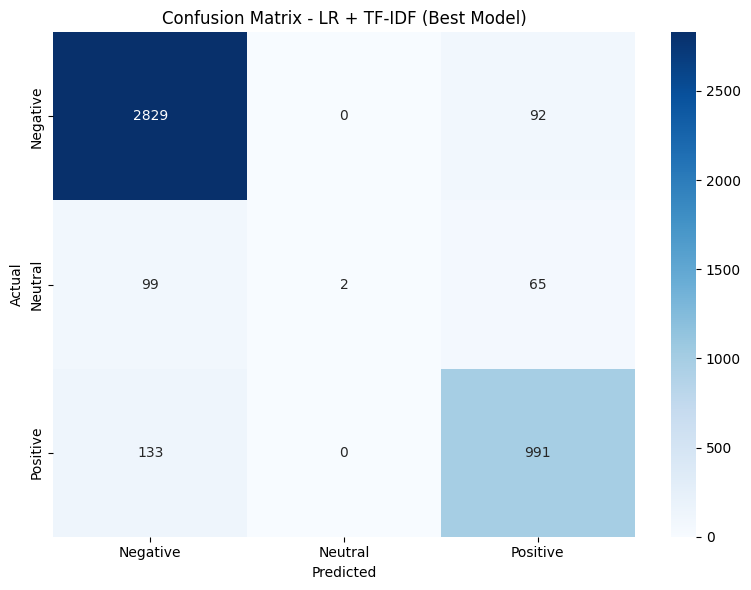

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Plot confusion matrix for best model (LR + TF-IDF)
y_pred_best = lr_tfidf.predict(X_test_tfidf)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Confusion Matrix - LR + TF-IDF (Best Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Original
y_pred_original = lr_tfidf.predict(X_test_tfidf)
print("=== Original - LR + TF-IDF ===")
print(classification_report(y_test, y_pred_original,
      target_names=['Negative', 'Neutral', 'Positive']))

# Balanced
y_pred_balanced = lr_tfidf_bal.predict(X_test_tfidf)
print("=== Balanced - LR + TF-IDF ===")
print(classification_report(y_test, y_pred_balanced,
      target_names=['Negative', 'Neutral', 'Positive']))

=== Original - LR + TF-IDF ===
              precision    recall  f1-score   support

    Negative       0.92      0.97      0.95      2921
     Neutral       1.00      0.01      0.02       166
    Positive       0.86      0.88      0.87      1124

    accuracy                           0.91      4211
   macro avg       0.93      0.62      0.61      4211
weighted avg       0.91      0.91      0.89      4211

=== Balanced - LR + TF-IDF ===
              precision    recall  f1-score   support

    Negative       0.95      0.88      0.91      2921
     Neutral       0.15      0.35      0.21       166
    Positive       0.84      0.85      0.84      1124

    accuracy                           0.85      4211
   macro avg       0.65      0.69      0.66      4211
weighted avg       0.89      0.85      0.87      4211



### Step 3: Word Cloud

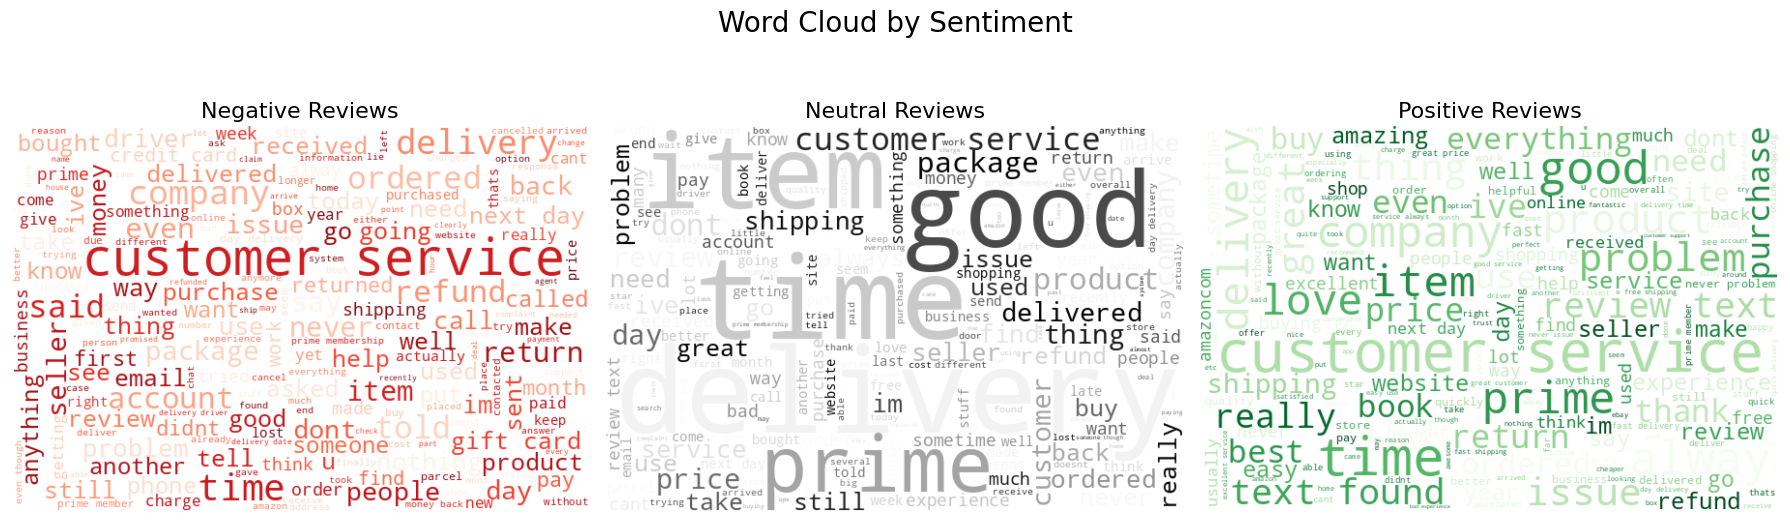

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Separate reviews by sentiment
negative_text = ' '.join(df[df['Sentiment'] == 'Negative']['Cleaned Text'])
positive_text = ' '.join(df[df['Sentiment'] == 'Positive']['Cleaned Text'])
neutral_text = ' '.join(df[df['Sentiment'] == 'Neutral']['Cleaned Text'])

# Plot Word Clouds
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Negative Word Cloud
wc_negative = WordCloud(width=600, height=400,
                        background_color='white',
                        colormap='Reds').generate(negative_text)
axes[0].imshow(wc_negative, interpolation='bilinear')
axes[0].set_title('Negative Reviews', fontsize=16)
axes[0].axis('off')

# Neutral Word Cloud
wc_neutral = WordCloud(width=600, height=400,
                       background_color='white',
                       colormap='Greys').generate(neutral_text)
axes[1].imshow(wc_neutral, interpolation='bilinear')
axes[1].set_title('Neutral Reviews', fontsize=16)
axes[1].axis('off')

# Positive Word Cloud
wc_positive = WordCloud(width=600, height=400,
                        background_color='white',
                        colormap='Greens').generate(positive_text)
axes[2].imshow(wc_positive, interpolation='bilinear')
axes[2].set_title('Positive Reviews', fontsize=16)
axes[2].axis('off')

plt.suptitle('Word Cloud by Sentiment', fontsize=20)
plt.tight_layout()
plt.show()

### Step 4: Model Comparison Visualization

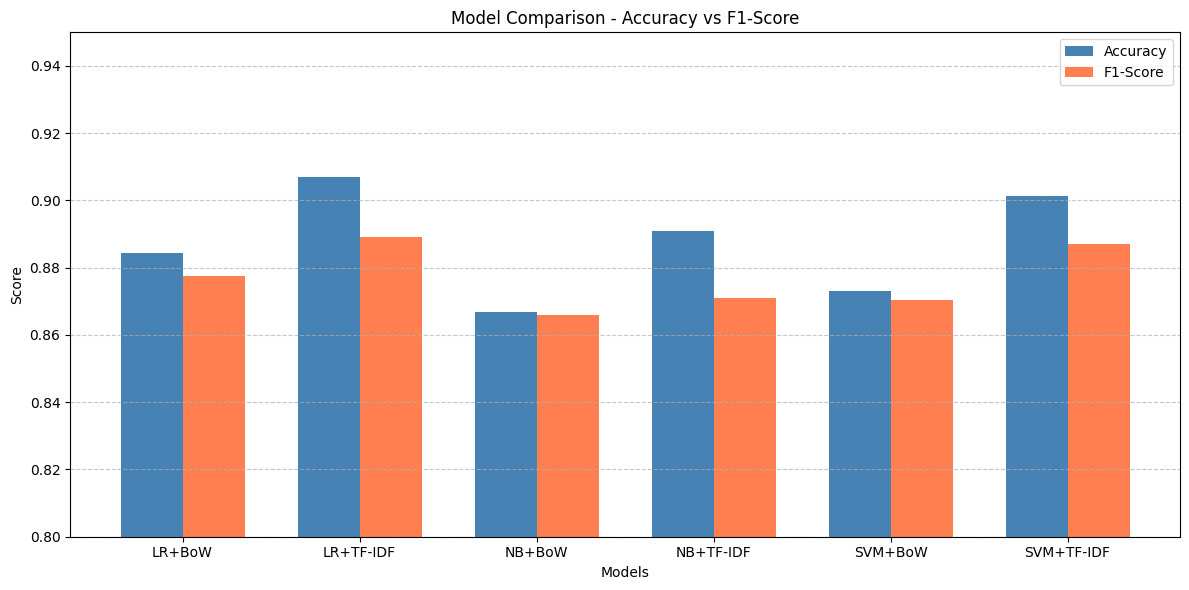

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data from results
models_names = ['LR+BoW', 'LR+TF-IDF', 'NB+BoW', 'NB+TF-IDF', 'SVM+BoW', 'SVM+TF-IDF']
accuracy = [0.8844, 0.9069, 0.8668, 0.8908, 0.8732, 0.9012]
f1_scores = [0.8776, 0.8892, 0.8658, 0.8711, 0.8704, 0.8870]

x = np.arange(len(models_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score', color='coral')

ax.set_xlabel('Models')
ax.set_ylabel('Score')
ax.set_title('Model Comparison - Accuracy vs F1-Score')
ax.set_xticks(x)
ax.set_xticklabels(models_names)
ax.set_ylim(0.8, 0.95)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()